# Statistical Foundation of Data Sciences - Assignment 8

**Student Information:**
- **Name:** Lavanya Garg  
- **Roll Number:** GF202345280 
- **Course:** CSU1658 - Statistical Foundation of Data Sciences  
- **Date:** Nov 3, 2025

---

🧠 Objective:

To predict whether a person has diabetes using the Pima Indians Diabetes dataset, and to compare Decision Tree performance using Entropy and Gini criteria.

In [13]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Model & visualization tools
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score


In [15]:
df = pd.read_csv(r"D:\sem 5\diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
target_col = "Outcome"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("🎯 Target column:", target_col)
print("📊 Feature columns:", feature_cols)


🎯 Target column: Outcome
📊 Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (537, 8)
Testing set size: (231, 8)


In [21]:
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
dt_entropy.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

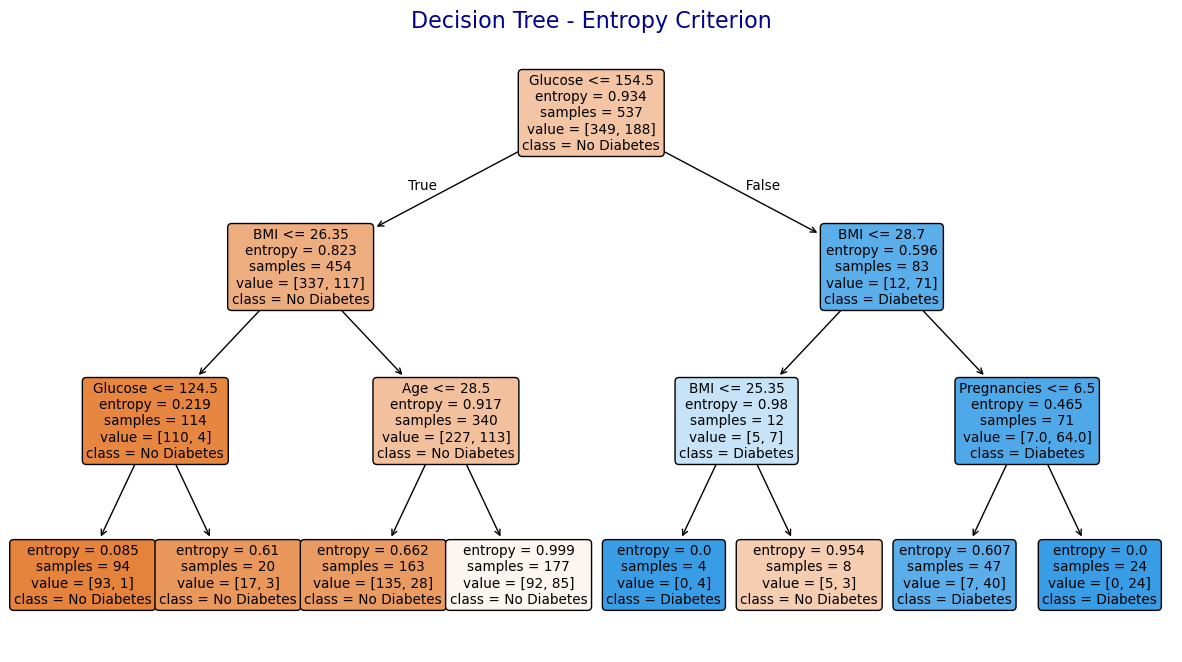

In [23]:
plt.figure(figsize=(15, 8))
plot_tree(dt_entropy,
          feature_names=feature_cols,
          class_names=['No Diabetes', 'Diabetes'],
          filled=True, rounded=True)
plt.title("Decision Tree - Entropy Criterion", fontsize=16, color='darkblue')
plt.show()


In [25]:
y_pred_entropy = dt_entropy.predict(X_test)
print("🔹 Accuracy (Entropy):", round(accuracy_score(y_test, y_pred_entropy), 3))


🔹 Accuracy (Entropy): 0.719


In [27]:
def entropy(p):
    return -np.sum(p * np.log2(p + 1e-9))

# Calculate parent entropy
p_yes = np.mean(y_train)
p_no = 1 - p_yes
entropy_parent = entropy(np.array([p_yes, p_no]))

threshold = 120
left = y_train[X_train['Glucose'] <= threshold]
right = y_train[X_train['Glucose'] > threshold]

p_left = [np.mean(left), 1 - np.mean(left)]
p_right = [np.mean(right), 1 - np.mean(right)]

entropy_left = entropy(np.array(p_left))
entropy_right = entropy(np.array(p_right))

w_left = len(left) / len(y_train)
w_right = len(right) / len(y_train)

entropy_split = w_left * entropy_left + w_right * entropy_right
info_gain = entropy_parent - entropy_split

print("🧮 Entropy of parent node:", round(entropy_parent, 3))
print("📉 Information Gain (Glucose):", round(info_gain, 3))


🧮 Entropy of parent node: 0.934
📉 Information Gain (Glucose): 0.133


In [29]:
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf_gini.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

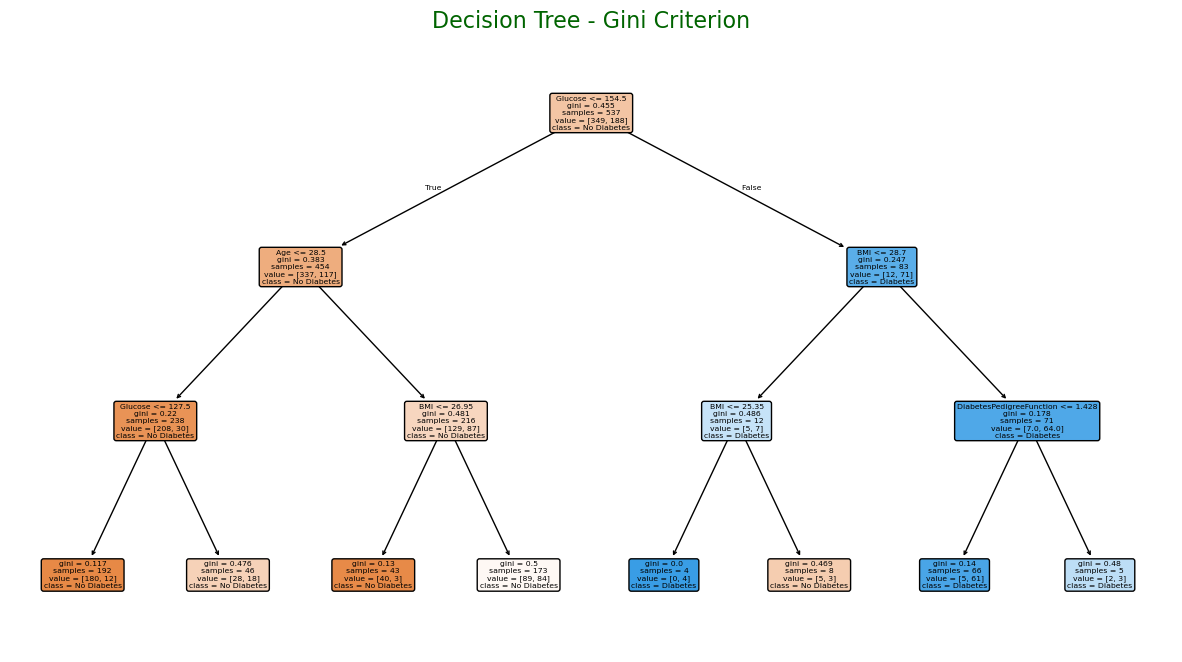

In [31]:
plt.figure(figsize=(15, 8))
plot_tree(clf_gini,
          feature_names=feature_cols,
          class_names=['No Diabetes', 'Diabetes'],
          filled=True, rounded=True)
plt.title("Decision Tree - Gini Criterion", fontsize=16, color='darkgreen')
plt.show()


In [33]:
y_pred_gini = clf_gini.predict(X_test)
print("🔹 Accuracy (Gini):", round(accuracy_score(y_test, y_pred_gini), 3))


🔹 Accuracy (Gini): 0.719


In [35]:
def gini(p):
    return 1 - np.sum(p**2)

gini_parent = gini(np.array([p_yes, p_no]))
gini_left = gini(np.array(p_left))
gini_right = gini(np.array(p_right))
gini_split = w_left * gini_left + w_right * gini_right
gini_gain = gini_parent - gini_split

print("🧮 Gini Index Reduction (Glucose):", round(gini_gain, 3))


🧮 Gini Index Reduction (Glucose): 0.081


Q) Why is “Glucose” the Root Node?

The feature Glucose produced the maximum impurity reduction in both criteria:

- Highest Information Gain (Entropy)

- Highest Gini Reduction (Gini Index)

This shows that Glucose is the most influential feature for predicting diabetes.